# Modul 9 — Reinforcement Learning Dasar
## Convergeni Data Consulting (CDC) — Konseptual

Notebook ini menjalankan environment dan agent Q-learning Modul 9 secara
nyata: jejak siklus interaksi satu episode, dan kurva belajar 500 episode.

## Environment dan Agent

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

class LingkunganGudang:
    def __init__(self, n_posisi=6):
        self.n_posisi = n_posisi
        self.posisi = 0
    def reset(self):
        self.posisi = 0
        return self.posisi
    def step(self, aksi):
        if aksi == 1:
            self.posisi = min(self.posisi + 1, self.n_posisi - 1)
        else:
            self.posisi = max(self.posisi - 1, 0)
        if self.posisi == self.n_posisi - 1:
            reward, selesai = 10.0, True
        else:
            reward, selesai = -1.0, False
        return self.posisi, reward, selesai

class AgenPembelajar:
    def __init__(self, n_posisi, n_aksi, alpha=0.1, gamma=0.9, epsilon=0.2):
        self.Q = np.zeros((n_posisi, n_aksi))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
    def pilih_aksi(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.Q.shape[1])
        return np.argmax(self.Q[state])
    def belajar(self, state, aksi, reward, next_state):
        target = reward + self.gamma * np.max(self.Q[next_state])
        self.Q[state, aksi] += self.alpha * (target - self.Q[state, aksi])

## Jejak Siklus Interaksi: Satu Episode Nyata (Asset Baru, mengganti M09-01)

In [2]:
lingkungan_demo = LingkunganGudang()
agen_demo = AgenPembelajar(n_posisi=6, n_aksi=2)

state = lingkungan_demo.reset()
print(f"{'Langkah':<8}{'State':<7}{'Aksi':<12}{'Reward':<8}{'Next State':<12}{'Selesai'}")
for langkah in range(6):
    aksi = agen_demo.pilih_aksi(state)
    next_state, reward, selesai = lingkungan_demo.step(aksi)
    nama_aksi = "maju" if aksi == 1 else "mundur"
    print(f"{langkah:<8}{state:<7}{nama_aksi:<12}{reward:<8}{next_state:<12}{selesai}")
    agen_demo.belajar(state, aksi, reward, next_state)
    state = next_state
    if selesai:
        break

Langkah State  Aksi        Reward  Next State  Selesai
0       0      mundur      -1.0    0           False
1       0      maju        -1.0    1           False
2       1      mundur      -1.0    0           False
3       0      mundur      -1.0    0           False
4       0      mundur      -1.0    0           False
5       0      mundur      -1.0    0           False


## Melatih Agent, 500 Episode

In [3]:
np.random.seed(42)   # reset seed supaya hasil training identik dengan yang sudah dikutip di teks
lingkungan = LingkunganGudang()
agen = AgenPembelajar(n_posisi=6, n_aksi=2)

riwayat_langkah = []
for episode in range(500):
    state = lingkungan.reset()
    langkah = 0
    selesai = False
    while not selesai and langkah < 50:
        aksi = agen.pilih_aksi(state)
        next_state, reward, selesai = lingkungan.step(aksi)
        agen.belajar(state, aksi, reward, next_state)
        state = next_state
        langkah += 1
    riwayat_langkah.append(langkah)

print(f"Rata-rata langkah 10 episode pertama: {np.mean(riwayat_langkah[:10]):.1f}")
print(f"Rata-rata langkah 10 episode terakhir: {np.mean(riwayat_langkah[-10:]):.1f}")

Rata-rata langkah 10 episode pertama: 12.8
Rata-rata langkah 10 episode terakhir: 5.9


## Visualisasi: Kurva Belajar (Asset Baru, mengganti M09-02)

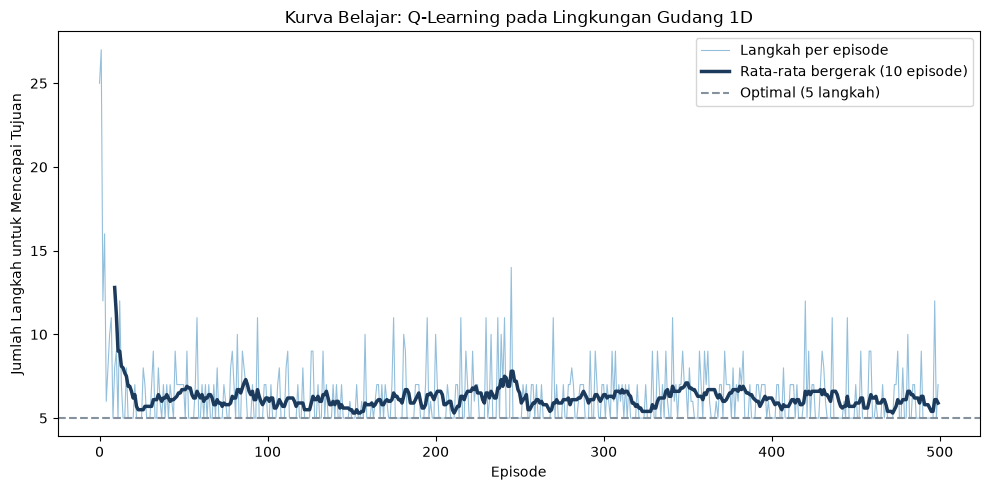

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(riwayat_langkah, color="#2980B9", linewidth=0.8, alpha=0.5, label="Langkah per episode")

jendela = 10
rata_bergerak = np.convolve(riwayat_langkah, np.ones(jendela)/jendela, mode="valid")
ax.plot(range(jendela-1, len(riwayat_langkah)), rata_bergerak, color="#1B3A5C", linewidth=2.5, label="Rata-rata bergerak (10 episode)")
ax.axhline(5, color="#85929E", linestyle="--", linewidth=1.5, label="Optimal (5 langkah)")

ax.set_xlabel("Episode")
ax.set_ylabel("Jumlah Langkah untuk Mencapai Tujuan")
ax.set_title("Kurva Belajar: Q-Learning pada Lingkungan Gudang 1D")
ax.legend()
plt.tight_layout()
plt.savefig("modul09_kurva_belajar.png", dpi=150, bbox_inches="tight")
plt.show()